In [1]:
from test_multicommodity import test_main, create_forcing, plot_result
from mcopt_misc import plot_network, run_mcopt
import sys
sys.path.append('../src/')
import numpy as np
from mcopt import McOpt, paris_topology

ierr=0 avg_it=0003 max(res)=2.2e-09 max(pres)=2.5e-09
   -1.97e+00<=UPDATE<=2.70e+00, deltat=1.00e-01
ierr=0 avg_it=0003 max(res)=2.3e-09 max(pres)=1.0e-08
it=1 var=1.00e+00
   -1.78e+00<=UPDATE<=2.00e+00, deltat=1.00e-01
ierr=0 avg_it=0003 max(res)=1.3e-09 max(pres)=6.0e-09
it=2 var=8.96e-01
   -1.60e+00<=UPDATE<=1.53e+00, deltat=1.00e-01
ierr=0 avg_it=0003 max(res)=6.3e-10 max(pres)=2.8e-09
it=3 var=8.07e-01
   -1.45e+00<=UPDATE<=1.20e+00, deltat=1.00e-01
ierr=0 avg_it=0003 max(res)=3.3e-10 max(pres)=1.5e-09
it=4 var=7.29e-01
   -1.30e+00<=UPDATE<=9.44e-01, deltat=1.00e-01
ierr=0 avg_it=0003 max(res)=2.0e-10 max(pres)=8.8e-10
it=5 var=6.57e-01
   -1.17e+00<=UPDATE<=7.50e-01, deltat=1.00e-01
ierr=0 avg_it=0003 max(res)=1.3e-10 max(pres)=5.8e-10
it=6 var=5.91e-01
   -1.06e+00<=UPDATE<=5.96e-01, deltat=1.00e-01
ierr=0 avg_it=0003 max(res)=9.1e-11 max(pres)=4.1e-10
it=7 var=5.30e-01
   -9.50e-01<=UPDATE<=4.73e-01, deltat=1.00e-01
ierr=0 avg_it=0003 max(res)=6.7e-11 max(pres)=3.0e-10
it=8

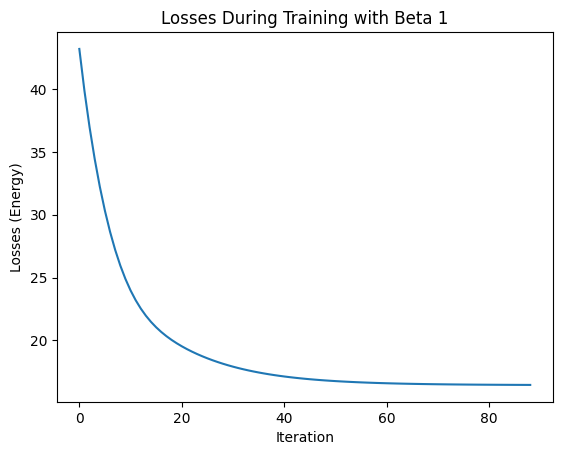

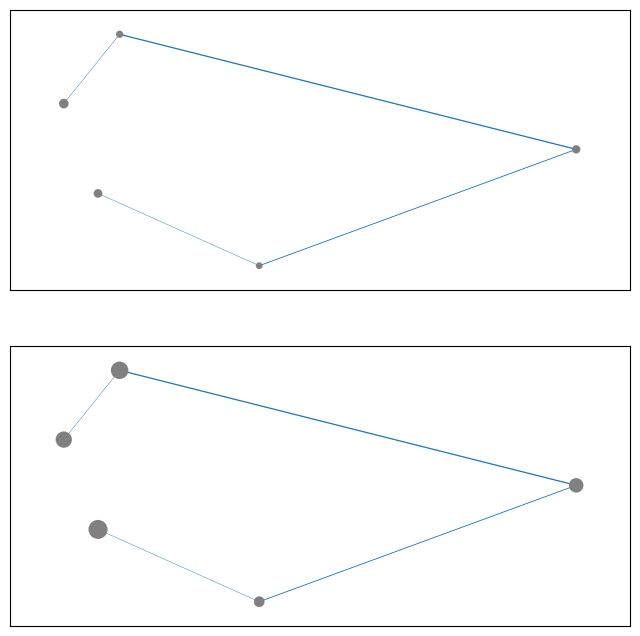

In [2]:
topo = np.array([[0, 1], [0, 2], [0, 3], [2, 3], [1, 2], [3, 4], [0, 4]],)
weights = np.array([1, 11, 10, 4, 5, 6, 1])
potentials, conductivity = test_main(topo.copy(), weights, 2, create_forcing(5, num_commodity=2), beta=1)
plot_result(topo, weights,  2, potentials, conductivity)

ierr=0 avg_it=0003 max(res)=2.2e-09 max(pres)=2.5e-09
   -1.95e+00<=UPDATE<=7.39e+00, deltat=1.00e-01
ierr=0 avg_it=0003 max(res)=4.7e-09 max(pres)=2.1e-08
it=1 var=1.57e+00
   -1.77e+00<=UPDATE<=7.14e+00, deltat=1.00e-01
ierr=0 avg_it=0003 max(res)=9.4e-10 max(pres)=1.4e-09
it=2 var=1.45e+00
   -1.61e+00<=UPDATE<=6.71e+00, deltat=1.00e-01
ierr=0 avg_it=0003 max(res)=9.0e-10 max(pres)=4.0e-09
it=3 var=1.29e+00
   -1.45e+00<=UPDATE<=6.20e+00, deltat=1.00e-01
ierr=0 avg_it=0003 max(res)=4.3e-10 max(pres)=1.9e-09
it=4 var=1.13e+00
   -1.31e+00<=UPDATE<=5.69e+00, deltat=1.00e-01
ierr=0 avg_it=0003 max(res)=2.1e-10 max(pres)=9.6e-10
it=5 var=9.75e-01
   -1.18e+00<=UPDATE<=5.18e+00, deltat=1.00e-01
ierr=0 avg_it=0003 max(res)=1.1e-10 max(pres)=5.1e-10
it=6 var=8.41e-01
   -1.06e+00<=UPDATE<=4.69e+00, deltat=1.00e-01
ierr=0 avg_it=0003 max(res)=6.5e-11 max(pres)=2.9e-10
it=7 var=7.24e-01
   -9.59e-01<=UPDATE<=4.24e+00, deltat=1.00e-01
ierr=0 avg_it=0003 max(res)=3.9e-11 max(pres)=1.8e-10
it=8

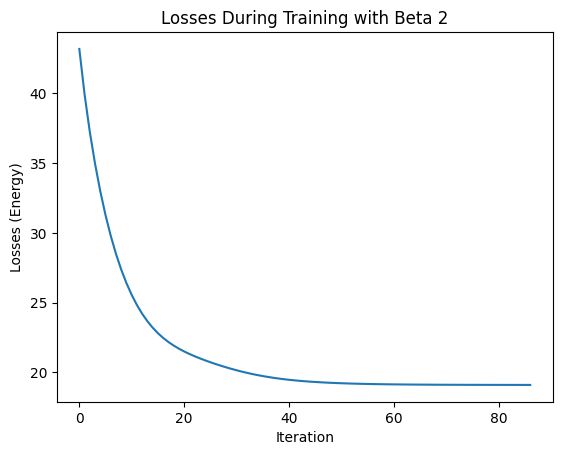

In [3]:
potentials, conductivity = test_main(topo.copy(), weights, 2, create_forcing(5, num_commodity=2), beta=2)

#### Compare With McOpt

In [4]:
def constrcut_mcopt(beta: float=1.0):
    method, coupling, museed, pflux, rho = "paris", "l1", 0, beta, 0.0   
    time_step, tot_time, relax_linsys, tau_cond_dyn, tau_cost_dyn = 0.5, 10000, 1.0e-5, 1.0e-1, 1.0e-1
    tau_cond_opt, tau_cost_opt = 1.0e-1, 1.0e-1
    VERBOSE = False
    mcopt = McOpt(method, coupling, museed, pflux, VERBOSE, rho, relax_linsys, tau_cond_dyn, tau_cost_dyn, time_step, tot_time, tau_cond_opt, tau_cost_opt)
    mcopt.ot_setup()
    return mcopt

In [5]:
def compare_mcopt_admk(beta: float=1.0):
    mcopt = constrcut_mcopt(beta=beta)
    forcing, conductivity_mcopt = run_mcopt(mcopt)
    topo, weights, forcing_ = mcopt.export_setup()
    potentials, conductivity_admk = test_main(topo.copy(), weights, len(forcing_), forcing_, beta=beta, max_iter=25)
    plot_network(mcopt.g, forcing, conductivity_mcopt, conductivity_admk)

* graph topology construction
Graph: Graph with 302 nodes and 359 edges
Forcing: [[ 7.91235900e+06 -1.14198250e+05 -3.45922617e+04 ... -1.62705497e+04
  -1.60048456e+04 -3.92271533e+04]
 [-1.13218685e+05  1.97543340e+07 -8.63645206e+04 ... -4.06217505e+04
  -3.99583822e+04 -9.79361891e+04]
 [-3.46390820e+04 -8.72296490e+04  6.04380800e+06 ... -1.24281619e+04
  -1.22252054e+04 -2.99634259e+04]
 ...
 [-1.63302210e+04 -4.11234758e+04 -1.24568812e+04 ...  2.84928800e+06
  -5.76344102e+03 -1.41259335e+04]
 [-1.60640808e+04 -4.04532699e+04 -1.22538664e+04 ... -5.76363417e+03
   2.80285200e+06 -1.38957174e+04]
 [-3.92573508e+04 -9.88595751e+04 -2.99459606e+04 ... -1.40851513e+04
  -1.38551355e+04  6.84960100e+06]]
* running [dynamics]
	convergence achieved [dynamics]
* export fluxes
* export cost
ierr=0 avg_it=0006 max(res)=8.1e-09 max(pres)=9.6e-07
   5.94e+01<=UPDATE<=3.88e+04, deltat=1.03e-04
ierr=0 avg_it=0006 max(res)=9.9e-09 max(pres)=2.2e-06
it=1 var=2.25e+03
   4.42e+01<=UPDATE<=1.80e

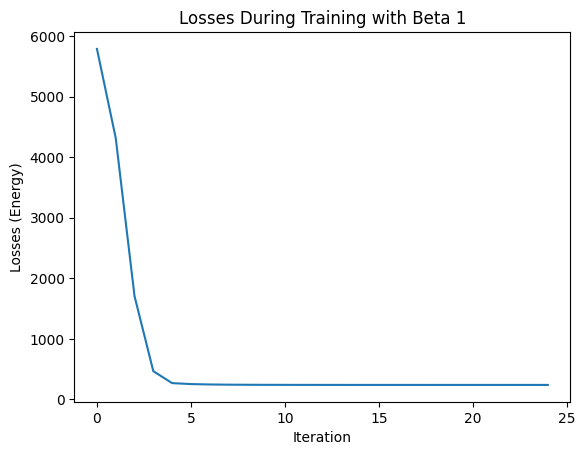

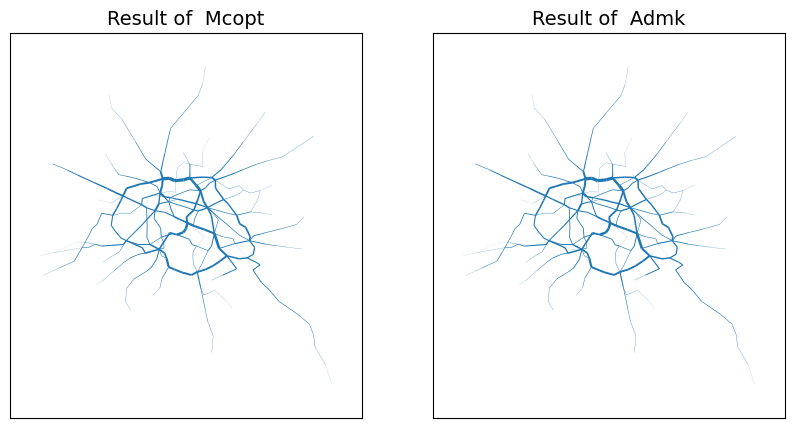

In [6]:
compare_mcopt_admk(1)

* graph topology construction
Graph: Graph with 302 nodes and 359 edges
Forcing: [[ 7.91235900e+06 -1.14198250e+05 -3.45922617e+04 ... -1.62705497e+04
  -1.60048456e+04 -3.92271533e+04]
 [-1.13218685e+05  1.97543340e+07 -8.63645206e+04 ... -4.06217505e+04
  -3.99583822e+04 -9.79361891e+04]
 [-3.46390820e+04 -8.72296490e+04  6.04380800e+06 ... -1.24281619e+04
  -1.22252054e+04 -2.99634259e+04]
 ...
 [-1.63302210e+04 -4.11234758e+04 -1.24568812e+04 ...  2.84928800e+06
  -5.76344102e+03 -1.41259335e+04]
 [-1.60640808e+04 -4.04532699e+04 -1.22538664e+04 ... -5.76363417e+03
   2.80285200e+06 -1.38957174e+04]
 [-3.92573508e+04 -9.88595751e+04 -2.99459606e+04 ... -1.40851513e+04
  -1.38551355e+04  6.84960100e+06]]
* running [dynamics]
	convergence achieved [dynamics]
* export fluxes
* export cost
ierr=0 avg_it=0006 max(res)=8.1e-09 max(pres)=9.6e-07
   3.33e+01<=UPDATE<=2.23e+04, deltat=1.03e-04
ierr=0 avg_it=0005 max(res)=9.8e-09 max(pres)=1.1e-06
it=1 var=1.40e+03
   2.73e+01<=UPDATE<=7.29e

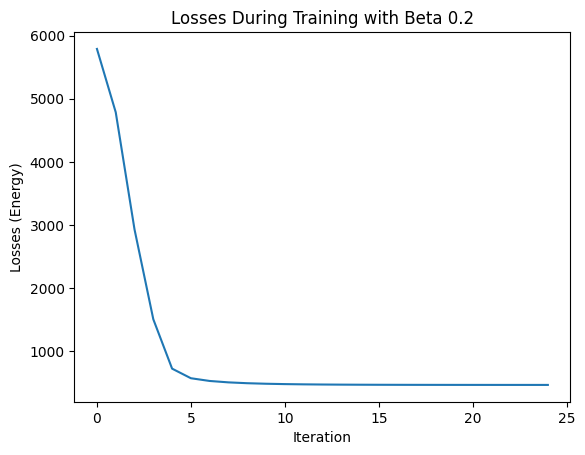

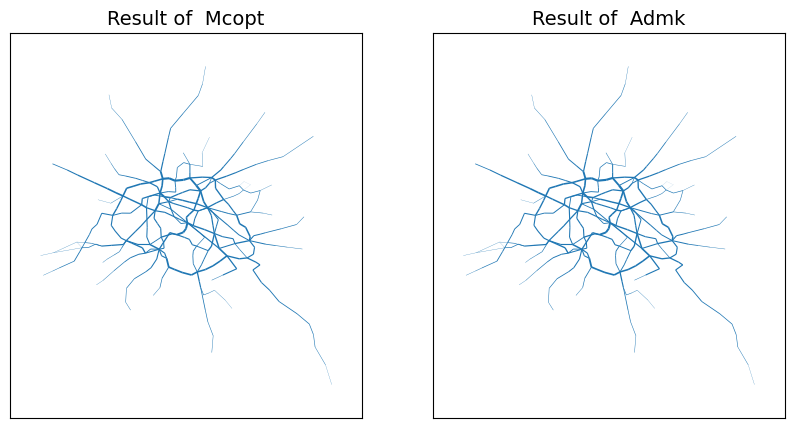

In [7]:
compare_mcopt_admk(0.2)

* graph topology construction
Graph: Graph with 302 nodes and 359 edges
Forcing: [[ 7.91235900e+06 -1.14198250e+05 -3.45922617e+04 ... -1.62705497e+04
  -1.60048456e+04 -3.92271533e+04]
 [-1.13218685e+05  1.97543340e+07 -8.63645206e+04 ... -4.06217505e+04
  -3.99583822e+04 -9.79361891e+04]
 [-3.46390820e+04 -8.72296490e+04  6.04380800e+06 ... -1.24281619e+04
  -1.22252054e+04 -2.99634259e+04]
 ...
 [-1.63302210e+04 -4.11234758e+04 -1.24568812e+04 ...  2.84928800e+06
  -5.76344102e+03 -1.41259335e+04]
 [-1.60640808e+04 -4.04532699e+04 -1.22538664e+04 ... -5.76363417e+03
   2.80285200e+06 -1.38957174e+04]
 [-3.92573508e+04 -9.88595751e+04 -2.99459606e+04 ... -1.40851513e+04
  -1.38551355e+04  6.84960100e+06]]
* running [dynamics]
	convergence achieved [dynamics]
* export fluxes
* export cost
ierr=0 avg_it=0006 max(res)=8.1e-09 max(pres)=9.6e-07
   1.05e+02<=UPDATE<=6.75e+04, deltat=1.03e-04
ierr=0 avg_it=0006 max(res)=7.0e-09 max(pres)=3.0e-06
it=1 var=3.43e+03
   6.83e+01<=UPDATE<=7.37e

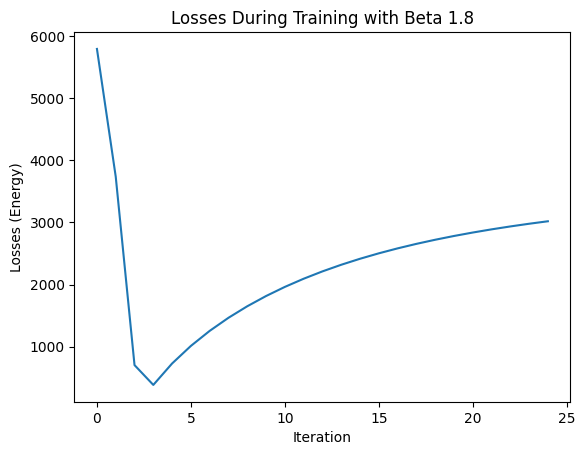

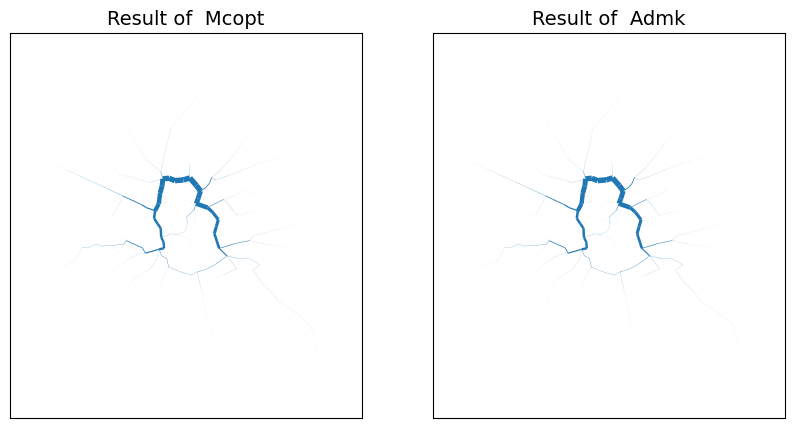

In [8]:
compare_mcopt_admk(1.8)